# Classification - Example
In this script we demonstrate how a Machine Learning workflow can look like when you use a train, validation and test set. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Loading Data

In [2]:
# This code is merely executed to see the description and target names in a smooth way
iris = load_iris()

In [3]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Storing/Loading the data in the way it will be used

In [5]:
X, y = load_iris(return_X_y=True, as_frame=True)

# Only choose two variables for my model
X = X[['sepal length (cm)', 'sepal width (cm)']]

In [6]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB
None


In [7]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [8]:
print(y.info())

<class 'pandas.core.series.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: target
Non-Null Count  Dtype
--------------  -----
150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB
None


# Train, Validation, and Test Set

In [9]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

# EDA
We are only allowed to explore / learn things on the training data when creating our model. 

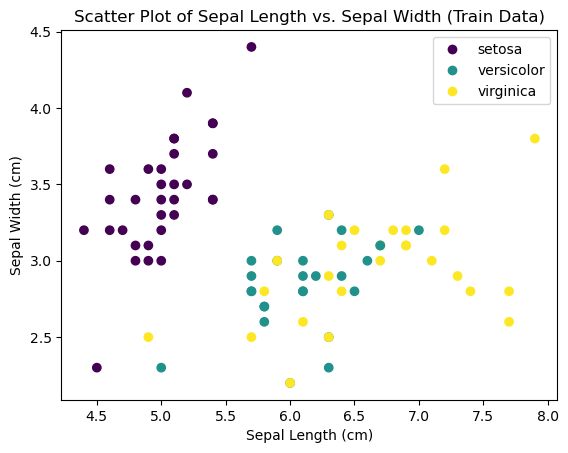

In [10]:
classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)

In [11]:
X_train.head()

,sepal length (cm),sepal width (cm)
72,6.3,2.5
62,6.0,2.2
74,6.4,2.9
19,5.1,3.8
93,5.0,2.3


In [12]:
y_train.head(10)

72     1
62     1
74     1
19     0
93     1
0      0
91     1
86     1
120    2
137    2
Name: target, dtype: int64

In [13]:
# 0 = 'setosa', 1 = 'versicolor', 2 = 'virginica'
y_train.value_counts()

target
0    32
1    26
2    26
Name: count, dtype: int64

# Training 2 different models

In [14]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_val)

In [15]:
tree_clf = DecisionTreeClassifier()

# Finding the best hyperparameter through GridSearch.
hyper_params = {'max_depth':(None, 1, 2, 5, 10)}
clf = GridSearchCV(tree_clf, hyper_params)

clf.fit(X_train, y_train)
clf_pred = clf.predict(X_val)

In [16]:

rf = RandomForestClassifier(random_state=39)


rf_params = {
'n_estimators': (50, 100, 200),     
'max_depth': (None, 2, 5, 10),       
'max_features': ('sqrt', None),      
}

rf_grid = GridSearchCV(rf, rf_params)
rf_grid.fit(X_train, y_train)            
rf_pred = rf_grid.predict(X_val)       


In [17]:
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC()),
])

svm_params = {
    'svc__C': (0.1, 1, 10, 100),
    'svc__gamma': ('scale', 0.01, 0.1, 1),
    'svc__kernel': ('linear', 'rbf'),
}

svm_grid = GridSearchCV(svm, svm_params)
svm_grid.fit(X_train, y_train)
svm_pred = svm_grid.predict(X_val)


In [18]:
print(clf.best_params_)
print(rf_grid.best_params_)
print(svm_grid.best_params_)
pd.DataFrame(clf.cv_results_)

{'max_depth': 2}
{'max_depth': 2, 'max_features': 'sqrt', 'n_estimators': 50}
{'svc__C': 100, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003742,0.006994,0.000400,0.000490,None,{'max_depth': None},0.588235,0.647059,0.764706,0.764706,0.6250,0.677941,0.073294,3
1,0.002000,0.000895,0.001600,0.000801,1,{'max_depth': 1},0.647059,0.705882,0.705882,0.647059,0.5625,0.653676,0.052634,5
2,0.004165,0.005612,0.000400,0.000800,2,{'max_depth': 2},0.764706,0.647059,0.823529,0.882353,0.6250,0.748529,0.099349,1
3,0.004254,0.005845,0.001125,0.001050,5,{'max_depth': 5},0.705882,0.647059,0.823529,0.823529,0.5625,0.712500,0.101471,2
4,0.002816,0.000285,0.002038,0.000077,10,{'max_depth': 10},0.529412,0.647059,0.764706,0.764706,0.6250,0.666176,0.089646,4


## Choosing the best model through validation set

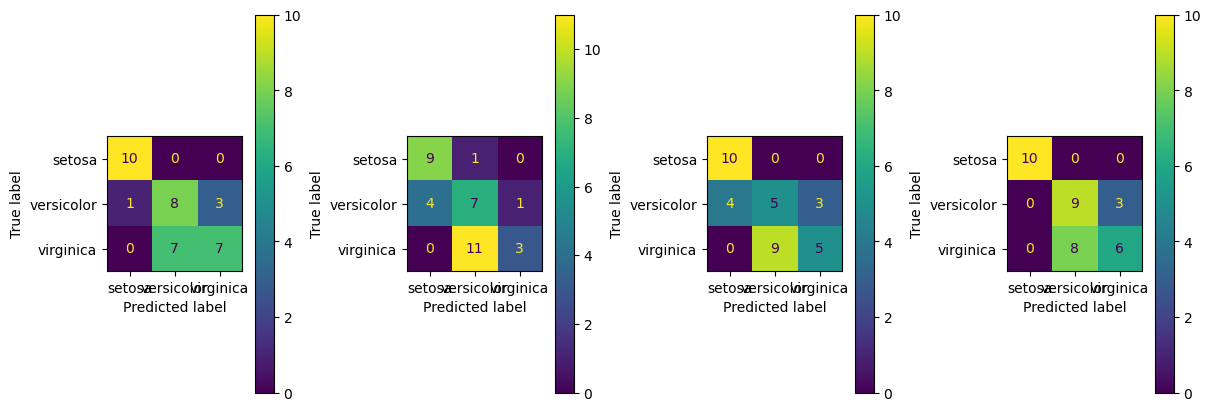

In [19]:
# These names were obtained above
target_names_iris = ['setosa', 'versicolor', 'virginica']

cm1 = confusion_matrix(y_val, log_reg_pred)
cm2 = confusion_matrix(y_val, clf_pred)
cm3 = confusion_matrix(y_val, rf_pred)
cm4 = confusion_matrix(y_val, svm_pred)

fig, axs = plt.subplots(1, 4, figsize = (12, 4), layout='constrained')
ConfusionMatrixDisplay(cm1, display_labels = target_names_iris).plot(ax=axs[0])
ConfusionMatrixDisplay(cm2, display_labels = target_names_iris).plot(ax=axs[1])
ConfusionMatrixDisplay(cm3, display_labels = target_names_iris).plot(ax=axs[2])
ConfusionMatrixDisplay(cm4, display_labels = target_names_iris).plot(ax=axs[3])

In [20]:
print(classification_report(y_val, log_reg_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36



In [21]:
print(classification_report(y_val, clf_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.69      0.90      0.78        10
  versicolor       0.37      0.58      0.45        12
   virginica       0.75      0.21      0.33        14

    accuracy                           0.53        36
   macro avg       0.60      0.57      0.52        36
weighted avg       0.61      0.53      0.50        36



In [22]:
print(classification_report(y_val, rf_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.71      1.00      0.83        10
  versicolor       0.36      0.42      0.38        12
   virginica       0.62      0.36      0.45        14

    accuracy                           0.56        36
   macro avg       0.57      0.59      0.56        36
weighted avg       0.56      0.56      0.54        36



In [23]:
print(classification_report(y_val, svm_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.53      0.75      0.62        12
   virginica       0.67      0.43      0.52        14

    accuracy                           0.69        36
   macro avg       0.73      0.73      0.71        36
weighted avg       0.71      0.69      0.69        36



# Evaluating chosen model through test set

The results are extremely good since this is a "toy dataset". In reality we do not expect numbers that are as perfect as those below. 

In [24]:
# Now we retrain our model on the train + validation data. 
Svm_final = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(C=100, gamma=0.01, kernel='rbf')),
]).fit(X_train_full, y_train_full)
pred_test = Svm_final.predict(X_test)

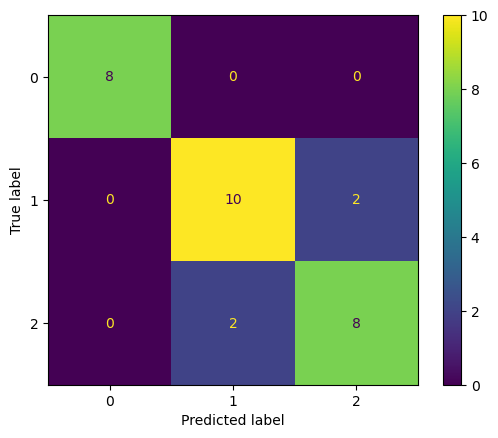

In [25]:
cm_test = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm_test).plot()

In [26]:
print(classification_report(y_test, pred_test, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.83      0.83      0.83        12
   virginica       0.80      0.80      0.80        10

    accuracy                           0.87        30
   macro avg       0.88      0.88      0.88        30
weighted avg       0.87      0.87      0.87        30



# Add a random forest and SVM model (use GridSearch in both cases) to the modelling flow. 
Explain in short how the models works and what you have done. 